# Experiment 4a: LSTM-GATv2 Per-Timestep (No Residual)

Per-timestep LSTM-GATv2 **without residual connection**.

**Motivation:** The v2 model (with residual) produced uniform attention
(entropy ratio 0.992) because the residual path bypasses the GAT entirely.
Removing the residual forces all information through the attention layer.

**Architecture**: Shared LSTM -> GATv2 (full attention, per timestep, NO residual) -> Position output

**Key question:** Does attention sharpen when the model cannot bypass the GAT?

## 1. Setup

In [72]:
!pip install -q tensorflow>=2.16.0 keras-tuner empyrical-reloaded spektral

In [73]:
import os
import sys

if 'google.colab' in str(get_ipython()):
    if not os.path.exists('/content/repo'):
        !git clone https://github.com/adam-909/4yp.git /content/repo
    else:
        !cd /content/repo && git pull
    os.chdir('/content/repo/4YP-main')
else:
    os.chdir('/home/adam/new4YP/4YP-main')

sys.path.insert(0, os.getcwd())
print(f"Working directory: {os.getcwd()}")

Already up to date.
Working directory: /content/repo/4YP-main


In [74]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime

from empyrical import (
    sharpe_ratio, sortino_ratio, max_drawdown,
    annual_return, annual_volatility, calmar_ratio,
)

import random

import tensorflow as tf

print(f"TensorFlow version: {tf.__version__}")

TensorFlow version: 2.19.0


## 2. Configuration

In [ ]:
# Experiment identification
EXPERIMENT_NAME = "4a_GATv2_per_ts_nores"
SEED = 41

# Set all seeds
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

# Training/Test Configuration
TRAIN_START = 2011
TEST_START = 2017
TEST_END = 2023

VOL_TARGET = 0.15

# Stride: 20 = non-overlapping independent windows
TRAIN_STRIDE = 20

# Model Configuration
TOTAL_TIME_STEPS = 20
TRAIN_VALID_RATIO = 0.8
NUM_EPOCHS = 300
EARLY_STOPPING_PATIENCE = 25

# GATv2 Hyperparameters
HIDDEN_LAYER_SIZE = 16
GAT_UNITS = 8
ATTN_HEADS = 3
LSTM_DROPOUT = 0.5
ATTN_DROPOUT = 0.3
LEARNING_RATE = 0.0005
MAX_GRADIENT_NORM = 1.0
NUM_GAT_LAYERS = 2
BATCH_SIZE = 57

# Results base directory
if 'google.colab' in str(get_ipython()):
    from google.colab import drive
    drive.mount('/content/drive')
    RESULTS_BASE = "/content/drive/MyDrive/FINAL_RESULTS"
else:
    RESULTS_BASE = "FINAL_RESULTS"

print(f"Experiment: {EXPERIMENT_NAME} (seed={SEED})")
print(f"Train: {TRAIN_START}-{TEST_START}")
print(f"Test:  {TEST_START}-{TEST_END}")
print(f"Model: LSTM-GATv2 Per-Timestep (NO RESIDUAL)")
print(f"  Stride: {TRAIN_STRIDE}")
print(f"  LSTM hidden: {HIDDEN_LAYER_SIZE}, dropout: {LSTM_DROPOUT}")
print(f"  GAT units: {GAT_UNITS}, heads: {ATTN_HEADS}, layers: {NUM_GAT_LAYERS}")
print(f"  Attention dropout: {ATTN_DROPOUT}")
print(f"  LR: {LEARNING_RATE}, clip norm: {MAX_GRADIENT_NORM}")
print(f"  Batch size: {BATCH_SIZE}")
print(f"  Residual: REMOVED")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Experiment: 4a_GATv2_per_ts_nores (seed=41)
Train: 2011-2017
Test:  2017-2023
Model: LSTM-GATv2 Per-Timestep (NO RESIDUAL)
  Stride: 20
  LSTM hidden: 10, dropout: 0.5
  GAT units: 8, heads: 2, layers: 1
  Attention dropout: 0.3
  LR: 0.0005, clip norm: 1.0
  Batch size: 57
  Residual: REMOVED


## 3. Helper Functions

In [76]:
def calc_daily_returns(df, returns_col="captured_returns"):
    num_tickers = df["identifier"].nunique()
    daily_ret = df.groupby("time")[returns_col].sum() / num_tickers
    daily_ret.index = pd.to_datetime(daily_ret.index)
    return daily_ret.sort_index()


def calc_vol_scaled_returns(daily_returns, target_vol=0.15):
    current_vol = daily_returns.std() * np.sqrt(252)
    if current_vol > 0:
        return daily_returns * (target_vol / current_vol)
    return daily_returns


def calc_metrics(daily_returns, name="Strategy"):
    return {
        "Strategy": name,
        "E[Ret.]": annual_return(daily_returns),
        "Vol.": annual_volatility(daily_returns),
        "Sharpe": sharpe_ratio(daily_returns),
        "Sortino": sortino_ratio(daily_returns),
        "Max DD": -max_drawdown(daily_returns),
        "Calmar": calmar_ratio(daily_returns),
        "Hit Rate": (daily_returns > 0).mean(),
        "Avg P/L": daily_returns[daily_returns > 0].mean() / abs(daily_returns[daily_returns < 0].mean()) if (daily_returns < 0).any() else np.nan,
    }


def calc_metrics_vol_normalized(daily_returns, name="Strategy", target_vol=0.15):
    scaled = calc_vol_scaled_returns(daily_returns, target_vol)
    return calc_metrics(scaled, name + " (Vol-Norm)"), scaled


def display_metrics(metrics_dict):
    df = pd.DataFrame([metrics_dict]).set_index("Strategy")
    for col in ["E[Ret.]", "Vol.", "Max DD", "Hit Rate"]:
        if col in df.columns:
            df[col] = df[col].apply(lambda x: f"{x:.2%}")
    for col in ["Sharpe", "Sortino", "Calmar", "Avg P/L"]:
        if col in df.columns:
            df[col] = df[col].apply(lambda x: f"{x:.3f}")
    display(df)
    return df


def calc_yearly_sharpes(daily_returns):
    yearly = {}
    for year in sorted(daily_returns.index.year.unique()):
        yr_ret = daily_returns[daily_returns.index.year == year]
        yearly[year] = sharpe_ratio(yr_ret)
    return yearly


def plot_results(daily_returns_dict, title="Strategy Comparison"):
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    colors = plt.cm.tab10(np.linspace(0, 1, len(daily_returns_dict)))

    ax1 = axes[0, 0]
    for (name, returns), color in zip(daily_returns_dict.items(), colors):
        cum_ret = (1 + returns).cumprod() - 1
        ax1.plot(cum_ret.index, cum_ret.values, label=name, linewidth=1.5, color=color)
    ax1.set_title("Cumulative Returns")
    ax1.set_xlabel("Date")
    ax1.set_ylabel("Cumulative Return")
    ax1.legend(loc="upper left", fontsize=8)
    ax1.grid(True, alpha=0.3)

    ax2 = axes[0, 1]
    for (name, returns), color in zip(daily_returns_dict.items(), colors):
        cum = (1 + returns).cumprod()
        running_max = cum.cummax()
        drawdown = (cum - running_max) / running_max
        ax2.fill_between(drawdown.index, drawdown.values, 0, alpha=0.3, label=name, color=color)
    ax2.set_title("Drawdown")
    ax2.set_xlabel("Date")
    ax2.set_ylabel("Drawdown")
    ax2.legend(loc="lower left", fontsize=8)
    ax2.grid(True, alpha=0.3)

    ax3 = axes[1, 0]
    for (name, returns), color in zip(daily_returns_dict.items(), colors):
        rolling_sharpe = returns.rolling(252).mean() / returns.rolling(252).std() * np.sqrt(252)
        ax3.plot(rolling_sharpe.index, rolling_sharpe.values, label=name, linewidth=1, color=color)
    ax3.axhline(y=0, color="black", linestyle="--", linewidth=0.5)
    ax3.set_title("Rolling 252-Day Sharpe Ratio")
    ax3.set_xlabel("Date")
    ax3.set_ylabel("Sharpe Ratio")
    ax3.legend(loc="upper left", fontsize=8)
    ax3.grid(True, alpha=0.3)

    ax4 = axes[1, 1]
    yearly_data = {name: calc_yearly_sharpes(returns) for name, returns in daily_returns_dict.items()}
    yearly_df = pd.DataFrame(yearly_data)
    yearly_df.plot(kind="bar", ax=ax4, width=0.8)
    ax4.axhline(y=0, color="black", linestyle="--", linewidth=0.5)
    ax4.set_title("Yearly Sharpe Ratios")
    ax4.set_xlabel("Year")
    ax4.set_ylabel("Sharpe Ratio")
    ax4.legend(loc="upper right", fontsize=8)
    ax4.tick_params(axis="x", rotation=45)
    ax4.grid(True, alpha=0.3, axis="y")

    plt.suptitle(title, fontsize=14, fontweight="bold")
    plt.tight_layout()
    plt.show()

## 4. Data Loading

In [77]:
features_path = "data/straddle_features/features.csv"
if 'google.colab' in str(get_ipython()):
    features_path = "/content/drive/MyDrive/features.csv"

df = pd.read_csv(features_path)
df["date"] = pd.to_datetime(df["date"])

print(f"Loaded {len(df)} rows")
print(f"Date range: {df['date'].min()} to {df['date'].max()}")
print(f"Tickers: {df['ticker'].nunique()}")

Loaded 274384 rows
Date range: 2010-07-01 00:00:00 to 2023-08-30 00:00:00
Tickers: 88


In [78]:
from gml.graph_model_inputs import GraphModelFeatures

features = GraphModelFeatures(
    df=df,
    total_time_steps=TOTAL_TIME_STEPS,
    start_boundary=TRAIN_START,
    test_boundary=TEST_START,
    test_end=TEST_END,
    train_valid_ratio=TRAIN_VALID_RATIO,
    split_tickers_individually=True,
    time_features=False,
    train_valid_sliding=True,
)

# Apply stride for independent non-overlapping windows
train_data = {k: v[::TRAIN_STRIDE] for k, v in features.train.items()}
valid_data = {k: v[::TRAIN_STRIDE] for k, v in features.valid.items()}
test_data = features.test_sliding

print(f"Stride: {TRAIN_STRIDE}")
print(f"Training: {train_data['inputs'].shape}")
print(f"Validation: {valid_data['inputs'].shape}")
print(f"Test: {test_data['inputs'].shape}")

no lags


train _batch
After final stacking and culling:
inputs.shape: (1131, 88, 20, 10)
outputs.shape: (1131, 88, 20, 1)
active_entries.shape: (1131, 88, 20, 1)
identifier.shape: (1131, 88, 20, 1)
date.shape: (1131, 88, 20, 1)


valid _batch
After final stacking and culling:
inputs.shape: (269, 88, 20, 10)
outputs.shape: (269, 88, 20, 1)
active_entries.shape: (269, 88, 20, 1)
identifier.shape: (269, 88, 20, 1)
date.shape: (269, 88, 20, 1)


test _batch
After final stacking and culling:
inputs.shape: (70, 88, 20, 10)
outputs.shape: (70, 88, 20, 1)
active_entries.shape: (70, 88, 20, 1)
identifier.shape: (70, 88, 20, 1)
date.shape: (70, 88, 20, 1)


test sliding _batch
After final stacking and culling:
inputs.shape: (1400, 88, 20, 10)
outputs.shape: (1400, 88, 20, 1)
active_entries.shape: (1400, 88, 20, 1)
identifier.shape: (1400, 88, 20, 1)
date.shape: (1400, 88, 20, 1)
Stride: 20
Training: (57, 88, 20, 10)
Validation: (14, 88, 20, 10)
Test: (1400, 88, 20, 10)


## 5. Model Definition

In [79]:
from gml.graph_attention_v2 import build_lstm_gat_e2e_v3

num_tickers = train_data["inputs"].shape[1]
time_steps = train_data["inputs"].shape[2]
input_size = train_data["inputs"].shape[3]

print(f"Building LSTM-GATv2 E2E v3 (NO RESIDUAL):")
print(f"  num_tickers: {num_tickers}")
print(f"  time_steps: {time_steps}")
print(f"  input_size: {input_size}")

model = build_lstm_gat_e2e_v3(
    num_tickers=num_tickers,
    time_steps=time_steps,
    input_size=input_size,
    hidden_layer_size=HIDDEN_LAYER_SIZE,
    gat_units=GAT_UNITS,
    attn_heads=ATTN_HEADS,
    lstm_dropout=LSTM_DROPOUT,
    attn_dropout=ATTN_DROPOUT,
    learning_rate=LEARNING_RATE,
    max_gradient_norm=MAX_GRADIENT_NORM,
    num_gat_layers=NUM_GAT_LAYERS,
)

print(f"Total parameters: {model.count_params():,}")

Building LSTM-GATv2 E2E v3 (NO RESIDUAL):
  num_tickers: 88
  time_steps: 20
  input_size: 10
Total parameters: 1,185


## 6. Training

In [80]:
X_train = train_data["inputs"]
y_train = train_data["outputs"]
w_train = train_data["active_entries"]

X_valid = valid_data["inputs"]
y_valid = valid_data["outputs"]
w_valid = valid_data["active_entries"]

print(f"Training samples: {X_train.shape[0]}")
print(f"Validation samples: {X_valid.shape[0]}")

Training samples: 57
Validation samples: 14


In [81]:
early_stopping = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=EARLY_STOPPING_PATIENCE,
    restore_best_weights=True,
    verbose=1,
)

print("=" * 60)
print(f"Training {EXPERIMENT_NAME} (seed={SEED})")
print(f"  NO RESIDUAL CONNECTION")
print(f"  LSTM hidden: {HIDDEN_LAYER_SIZE}, GAT: {GAT_UNITS}x{ATTN_HEADS}")
print(f"  Dropout: LSTM={LSTM_DROPOUT}, Attn={ATTN_DROPOUT}")
print(f"  LR: {LEARNING_RATE}, clip: {MAX_GRADIENT_NORM}, batch: {BATCH_SIZE}")
print("=" * 60)

history = model.fit(
    X_train, y_train,
    sample_weight=w_train,
    validation_data=(X_valid, y_valid, w_valid),
    epochs=NUM_EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=[early_stopping],
    verbose=1,
)

Training 4a_GATv2_per_ts_nores (seed=41)
  NO RESIDUAL CONNECTION
  LSTM hidden: 10, GAT: 8x2
  Dropout: LSTM=0.5, Attn=0.3
  LR: 0.0005, clip: 1.0, batch: 57
Epoch 1/300
1/1 ━━━━━━━━━━━━━━━━━━━━ 148s 148s/step - loss: 0.1315 - val_loss: -0.6761
Epoch 2/300
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 475ms/step - loss: 0.1702 - val_loss: -0.7910
Epoch 3/300
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 462ms/step - loss: 0.0465 - val_loss: -0.8922
Epoch 4/300
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 449ms/step - loss: 0.0316 - val_loss: -0.9712
Epoch 5/300
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 447ms/step - loss: -0.0852 - val_loss: -1.0314
Epoch 6/300
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 454ms/step - loss: -0.1643 - val_loss: -1.0725
Epoch 7/300
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 444ms/step - loss: -0.1673 - val_loss: -1.1058
Epoch 8/300
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 458ms/step - loss: -0.2961 - val_loss: -1.1300
Epoch 9/300
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 445ms/step - loss: -0.2588 - val_loss: -1.1431
Epoch 10/300
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 463ms/step - loss: -

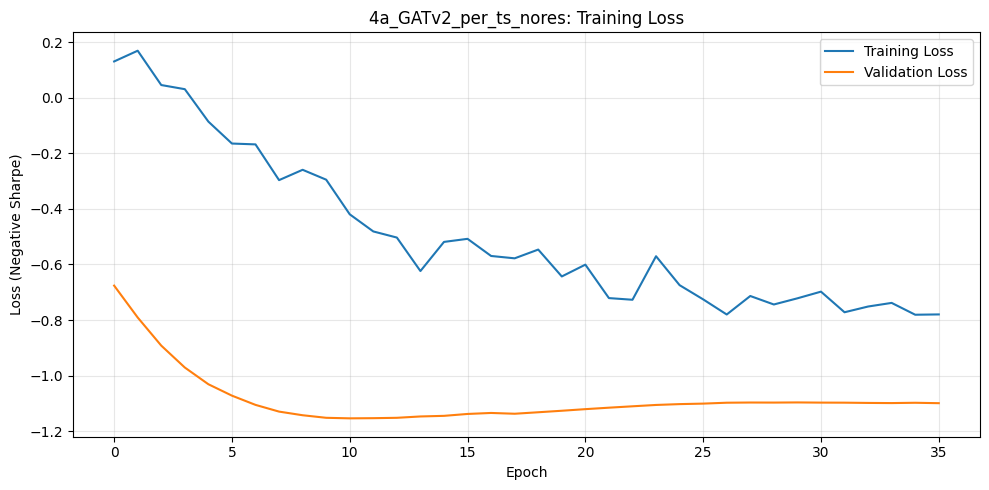

Epochs trained: 36
Best val loss: -1.1543


In [82]:
plt.figure(figsize=(10, 5))
plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss (Negative Sharpe)")
plt.title(f"{EXPERIMENT_NAME}: Training Loss")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Epochs trained: {len(history.history['loss'])}")
print(f"Best val loss: {min(history.history['val_loss']):.4f}")

## 7. Evaluation

In [83]:
X_test = test_data["inputs"]
predictions = model.predict(X_test)

print(f"Predictions shape: {predictions.shape}")

44/44 ━━━━━━━━━━━━━━━━━━━━ 48s 605ms/step
Predictions shape: (1400, 88, 20, 1)


In [84]:
# Extract last timestep only
positions = predictions[:, :, -1, 0].reshape(-1)
returns = test_data["outputs"][:, :, -1, 0].reshape(-1)
captured_returns = positions * returns

dates = test_data["date"][:, :, -1, 0].reshape(-1)
identifiers = test_data["identifier"][:, :, -1, 0].reshape(-1)

results_df = pd.DataFrame({
    "time": dates, "identifier": identifiers,
    "position": positions, "returns": returns,
    "captured_returns": captured_returns,
})

results_df["time"] = pd.to_datetime(results_df["time"])
results_df = results_df[results_df["identifier"] != "0"]

print(f"Results: {len(results_df)} rows")
results_df.head()

Results: 123200 rows


,time,identifier,position,returns,captured_returns
0,2017-01-03,AAPL,-0.060652,-0.009874,0.000599
1,2017-01-03,ABT,-0.060134,-0.002442,0.000147
2,2017-01-03,ACN,-0.058185,-0.008236,0.000479
3,2017-01-03,ADBE,-0.058685,-0.010764,0.000632
4,2017-01-03,AIG,-0.059697,-0.003832,0.000229


In [85]:
daily_returns = calc_daily_returns(results_df)

print("" + "=" * 60)
print(f"{EXPERIMENT_NAME} Results (Raw)")
print("=" * 60)

metrics_raw = calc_metrics(daily_returns, EXPERIMENT_NAME)
display_metrics(metrics_raw)

print(f"Volatility-Normalized (Target: {VOL_TARGET:.0%})")
metrics_norm, scaled_returns = calc_metrics_vol_normalized(daily_returns, EXPERIMENT_NAME, VOL_TARGET)
display_metrics(metrics_norm)

print("Yearly Sharpe Ratios:")
yearly_sharpes = calc_yearly_sharpes(daily_returns)
for year, sharpe_val in yearly_sharpes.items():
    print(f"  {year}: {sharpe_val:.4f}")

4a_GATv2_per_ts_nores Results (Raw)


,E[Ret.],Vol.,Sharpe,Sortino,Max DD,Calmar,Hit Rate,Avg P/L
Strategy,,,,,,,,
4a_GATv2_per_ts_nores,0.46%,0.58%,0.796,1.053,1.58%,0.291,59.14%,0.819


Volatility-Normalized (Target: 15%)


,E[Ret.],Vol.,Sharpe,Sortino,Max DD,Calmar,Hit Rate,Avg P/L
Strategy,,,,,,,,
4a_GATv2_per_ts_nores (Vol-Norm),11.42%,15.00%,0.796,1.053,35.03%,0.326,59.14%,0.819


Yearly Sharpe Ratios:
  2017: 3.3617
  2018: -0.2064
  2019: 2.6962
  2020: -0.6930
  2021: 1.4232
  2022: 0.6179


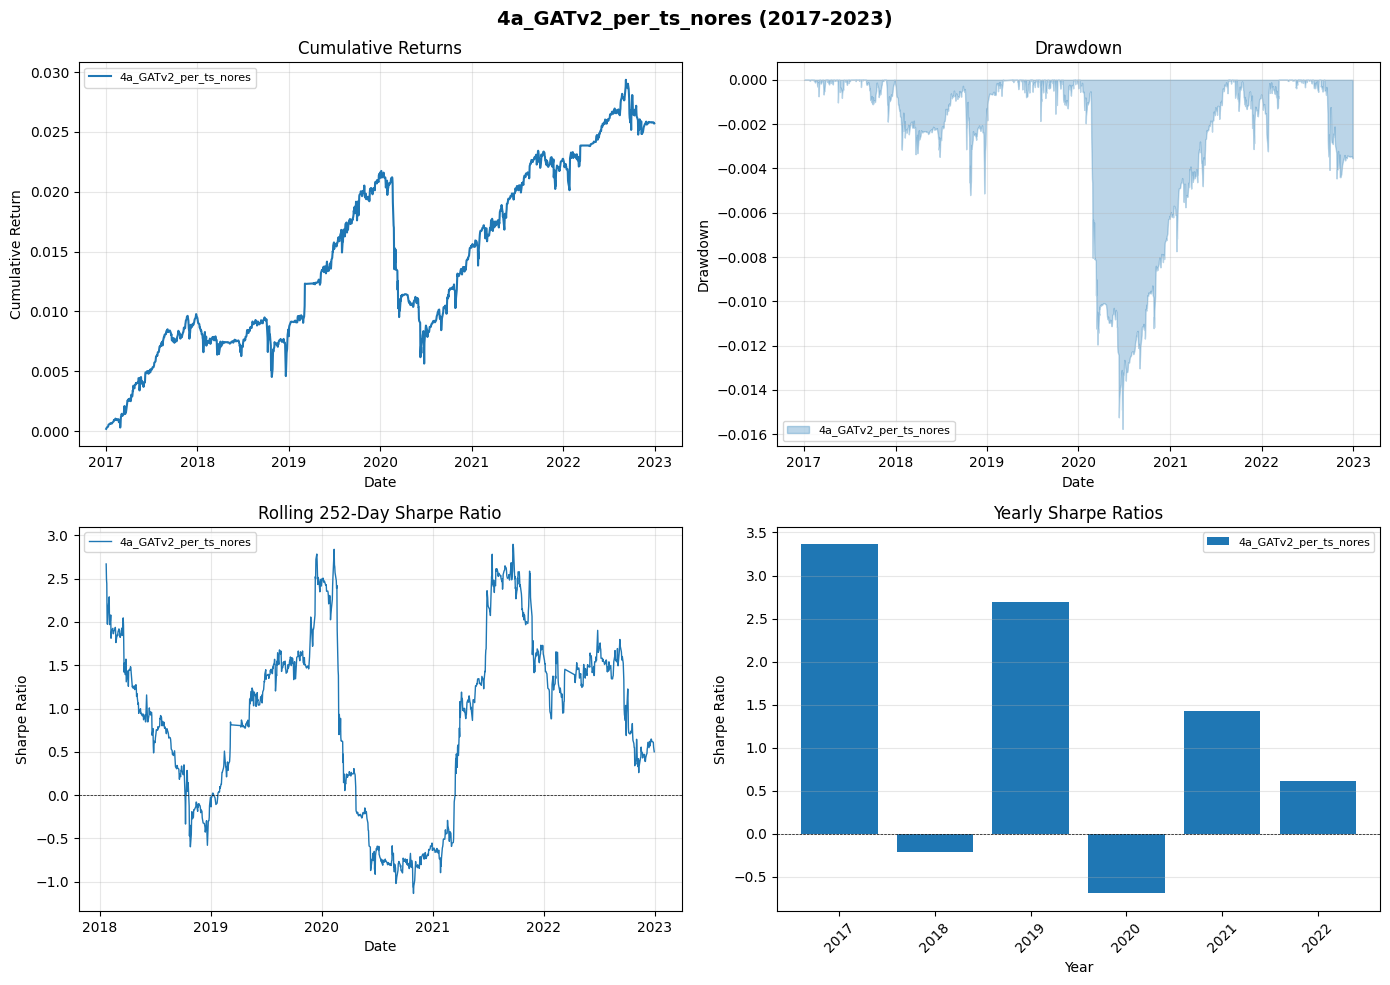

In [86]:
all_daily_returns = {EXPERIMENT_NAME: daily_returns}
plot_results(all_daily_returns, f"{EXPERIMENT_NAME} ({TEST_START}-{TEST_END})")

## 8. Attention Analysis

In [ ]:
from gml.graph_attention_v2 import extract_attention_weights_v2
from gml.experiment_utils import compute_graph_stats

# Extract attention for ALL test windows
print(f"Extracting attention for all {X_test.shape[0]} test windows...")
all_attn = extract_attention_weights_v2(model, X_test, gat_layer_name="gat_v2_0")
all_graphs_avg = all_attn.mean(axis=1)  # (N, 88, 88) avg across heads
print(f"Done: {all_graphs_avg.shape}")

# Test dates
test_dates_arr = pd.to_datetime(test_data["date"][:, 0, -1, 0])

# Entropy
entropy = -np.sum(all_graphs_avg * np.log(all_graphs_avg + 1e-9), axis=-1)
mean_entropy = entropy.mean()
max_entropy = np.log(all_graphs_avg.shape[-1])
print(f"Attention entropy: {mean_entropy:.3f} (uniform = {max_entropy:.3f})")
print(f"Entropy ratio: {mean_entropy / max_entropy:.3f} (lower = more focused)")

# Graph statistics
EDGE_THRESHOLD = 0.00
graph_stats = compute_graph_stats(all_graphs_avg, threshold=EDGE_THRESHOLD)
print(f"Edge statistics (threshold={EDGE_THRESHOLD}):")
print(f"  Mean edges: {graph_stats['num_edges'].mean():.1f}")
print(f"  Mean max attention: {graph_stats['max_attn'].mean():.4f}")

Extracting attention for all 1400 test windows...


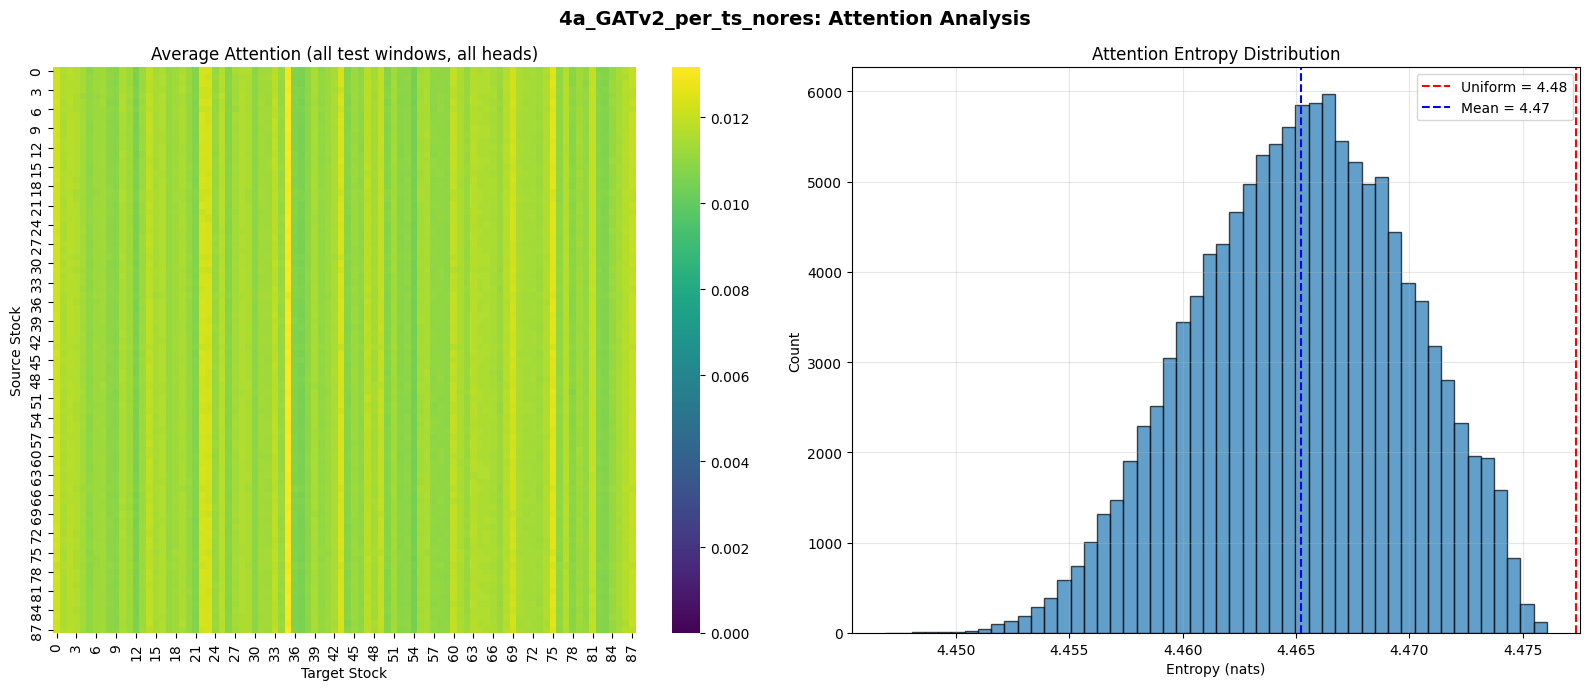

In [ ]:
# Heatmap + entropy distribution
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

avg_attn = all_graphs_avg.mean(axis=0)
sns.heatmap(avg_attn, ax=axes[0], cmap="viridis", vmin=0)
axes[0].set_title("Average Attention (all test windows, all heads)")
axes[0].set_xlabel("Target Stock")
axes[0].set_ylabel("Source Stock")

axes[1].hist(entropy.flatten(), bins=50, edgecolor="black", alpha=0.7)
axes[1].axvline(x=max_entropy, color="red", linestyle="--", label=f"Uniform = {max_entropy:.2f}")
axes[1].axvline(x=mean_entropy, color="blue", linestyle="--", label=f"Mean = {mean_entropy:.2f}")
axes[1].set_xlabel("Entropy (nats)")
axes[1].set_ylabel("Count")
axes[1].set_title("Attention Entropy Distribution")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.suptitle(f"{EXPERIMENT_NAME}: Attention Analysis", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

## 9. Graph Statistics Over Time

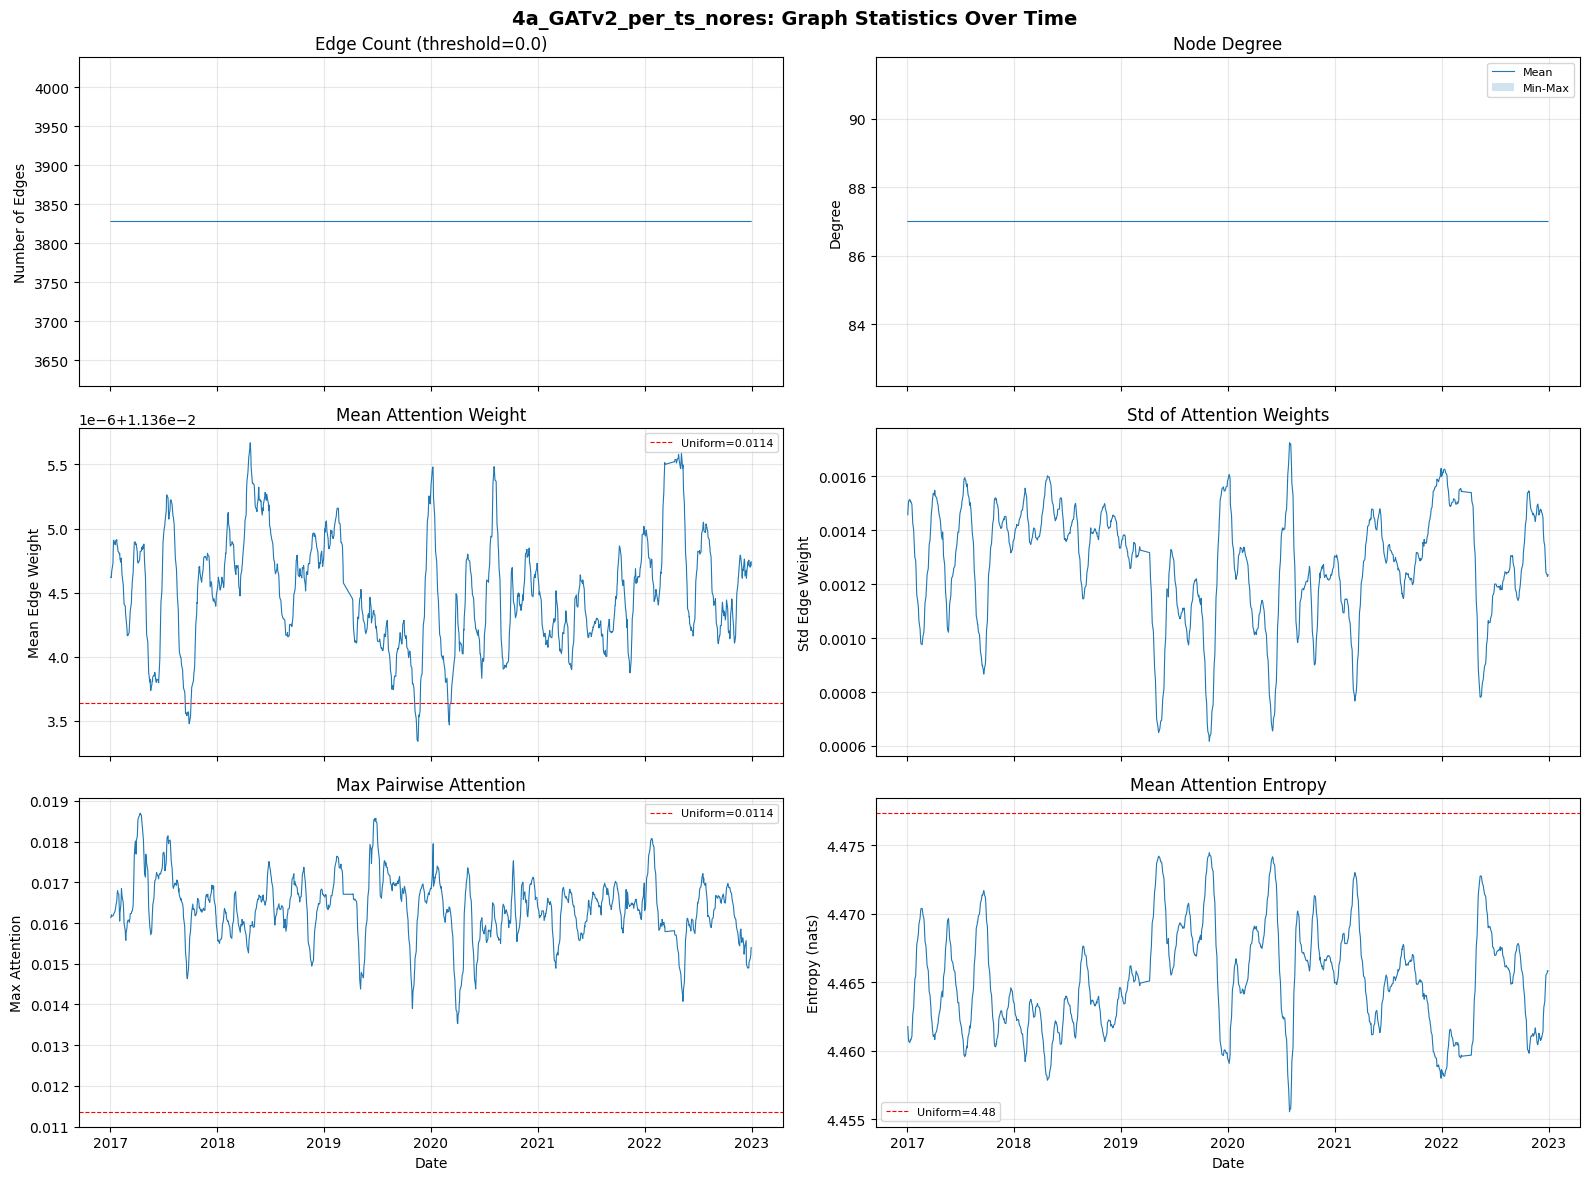

In [ ]:
fig, axes = plt.subplots(3, 2, figsize=(16, 12), sharex=True)

axes[0, 0].plot(test_dates_arr, graph_stats["num_edges"], linewidth=0.8)
axes[0, 0].set_ylabel("Number of Edges")
axes[0, 0].set_title(f"Edge Count (threshold={EDGE_THRESHOLD})")
axes[0, 0].grid(True, alpha=0.3)

axes[0, 1].plot(test_dates_arr, graph_stats["mean_degree"], linewidth=0.8, label="Mean")
axes[0, 1].fill_between(test_dates_arr, graph_stats["min_degree"], graph_stats["max_degree"], alpha=0.2, label="Min-Max")
axes[0, 1].set_ylabel("Degree")
axes[0, 1].set_title("Node Degree")
axes[0, 1].legend(fontsize=8)
axes[0, 1].grid(True, alpha=0.3)

uniform_val = 1 / all_graphs_avg.shape[-1]
axes[1, 0].plot(test_dates_arr, graph_stats["mean_edge_weight"], linewidth=0.8)
axes[1, 0].axhline(y=uniform_val, color="red", linestyle="--", linewidth=0.8, label=f"Uniform={uniform_val:.4f}")
axes[1, 0].set_ylabel("Mean Edge Weight")
axes[1, 0].set_title("Mean Attention Weight")
axes[1, 0].legend(fontsize=8)
axes[1, 0].grid(True, alpha=0.3)

axes[1, 1].plot(test_dates_arr, graph_stats["std_edge_weight"], linewidth=0.8)
axes[1, 1].set_ylabel("Std Edge Weight")
axes[1, 1].set_title("Std of Attention Weights")
axes[1, 1].grid(True, alpha=0.3)

axes[2, 0].plot(test_dates_arr, graph_stats["max_attn"], linewidth=0.8)
axes[2, 0].axhline(y=uniform_val, color="red", linestyle="--", linewidth=0.8, label=f"Uniform={uniform_val:.4f}")
axes[2, 0].set_ylabel("Max Attention")
axes[2, 0].set_title("Max Pairwise Attention")
axes[2, 0].set_xlabel("Date")
axes[2, 0].legend(fontsize=8)
axes[2, 0].grid(True, alpha=0.3)

uniform_ent = np.log(all_graphs_avg.shape[-1])
axes[2, 1].plot(test_dates_arr, graph_stats["mean_entropy"], linewidth=0.8)
axes[2, 1].axhline(y=uniform_ent, color="red", linestyle="--", linewidth=0.8, label=f"Uniform={uniform_ent:.2f}")
axes[2, 1].set_ylabel("Entropy (nats)")
axes[2, 1].set_title("Mean Attention Entropy")
axes[2, 1].set_xlabel("Date")
axes[2, 1].legend(fontsize=8)
axes[2, 1].grid(True, alpha=0.3)

plt.suptitle(f"{EXPERIMENT_NAME}: Graph Statistics Over Time", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

## 10. Interactive Graph Visualization

In [ ]:
import networkx as nx
import ipywidgets as widgets
from IPython.display import display, clear_output
from settings.default import ALL_TICKERS, BBG_SECTORS

SECTOR_COLORS = {
    "Information Technology": "#1f77b4", "Healthcare": "#2ca02c",
    "Financials": "#ff7f0e", "Consumer Discretionary": "#d62728",
    "Consumer Staples": "#9467bd", "Industrials": "#8c564b",
    "Communication Services": "#e377c2", "Energy": "#7f7f7f",
    "Utilities": "#bcbd22", "Real Estate": "#17becf",
}

tickers = sorted(ALL_TICKERS)
G_ref = nx.Graph()
for t in tickers:
    G_ref.add_node(t, sector=BBG_SECTORS.get(t, "Unknown"))

fixed_pos = nx.spring_layout(G_ref, k=2.5, iterations=100, seed=42)
node_colors = [SECTOR_COLORS.get(BBG_SECTORS.get(t, "Unknown"), "#cccccc") for t in tickers]

rolling_sharpe = daily_returns.rolling(252).mean() / daily_returns.rolling(252).std() * np.sqrt(252)

output_widget = widgets.Output()

def update_graph(window_idx):
    with output_widget:
        clear_output(wait=True)
        fig, (ax_graph, ax_sharpe) = plt.subplots(2, 1, figsize=(14, 16), gridspec_kw={"height_ratios": [3, 1]})

        adj = all_graphs_avg[window_idx]
        date_str = str(test_dates_arr[window_idx].date()) if window_idx < len(test_dates_arr) else "N/A"

        G = nx.Graph()
        for t in tickers:
            G.add_node(t)

        n = len(tickers)
        for i in range(n):
            for j in range(i + 1, n):
                w = (adj[i, j] + adj[j, i]) / 2
                if w > EDGE_THRESHOLD:
                    G.add_edge(tickers[i], tickers[j], weight=w)

        edges = G.edges(data=True)
        if len(edges) > 0:
            weights = [d["weight"] for _, _, d in edges]
            max_w = max(weights) if weights else 1.0
            for (u, v, d) in edges:
                w = d["weight"]
                width = 2.0 * w / max_w
                alpha = 0.3 + 0.7 * w / max_w
                x = [fixed_pos[u][0], fixed_pos[v][0]]
                y = [fixed_pos[u][1], fixed_pos[v][1]]
                ax_graph.plot(x, y, color="gray", linewidth=width, alpha=alpha, zorder=1)

        nx.draw_networkx_nodes(G, fixed_pos, node_color=node_colors, node_size=600, alpha=0.9, ax=ax_graph)
        nx.draw_networkx_labels(G, fixed_pos, font_size=6, font_weight="bold", ax=ax_graph)

        num_edges = G.number_of_edges()
        ax_graph.set_title(f"Learned Attention Graph at {date_str}  |  {num_edges} edges (threshold={EDGE_THRESHOLD})", fontsize=14, fontweight="bold")
        ax_graph.axis("off")

        ax_sharpe.plot(rolling_sharpe.index, rolling_sharpe.values, linewidth=1, color="blue")
        ax_sharpe.axhline(y=0, color="black", linestyle="--", linewidth=0.5)
        if window_idx < len(test_dates_arr):
            ax_sharpe.axvline(x=test_dates_arr[window_idx], color="red", linewidth=2, alpha=0.8)
        ax_sharpe.set_title("Rolling 252-Day Sharpe Ratio", fontsize=12)
        ax_sharpe.set_xlabel("Date")
        ax_sharpe.set_ylabel("Sharpe")
        ax_sharpe.grid(True, alpha=0.3)

        plt.tight_layout()
        plt.show()

slider = widgets.IntSlider(min=0, max=len(all_graphs_avg) - 1, step=1, value=0, description="Window:", continuous_update=False, layout=widgets.Layout(width="80%"))
widgets.interactive(update_graph, window_idx=slider)
display(slider, output_widget)
update_graph(0)

IntSlider(value=0, continuous_update=False, description='Window:', layout=Layout(width='80%'), max=1399)

Output()

## 11. Position Analysis

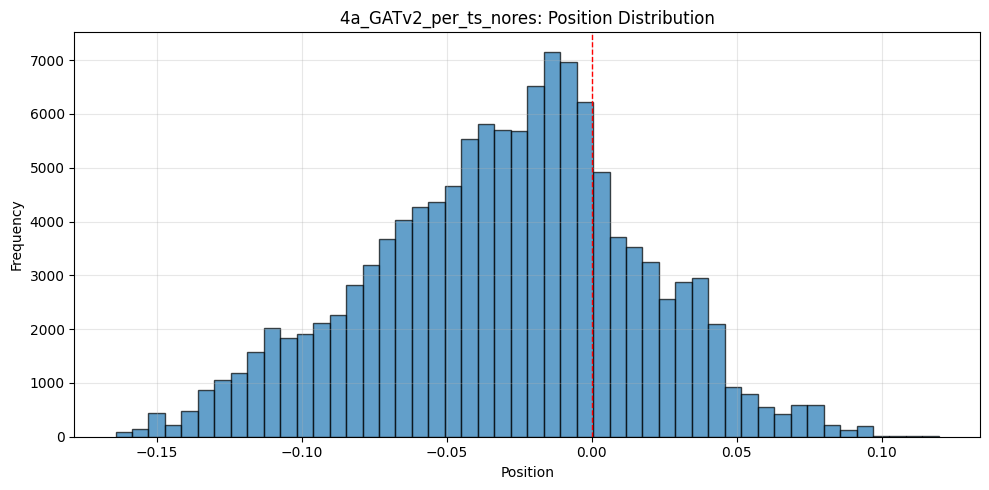

In [ ]:
plt.figure(figsize=(10, 5))
plt.hist(results_df["position"], bins=50, edgecolor="black", alpha=0.7)
plt.xlabel("Position")
plt.ylabel("Frequency")
plt.title(f"{EXPERIMENT_NAME}: Position Distribution")
plt.axvline(x=0, color="red", linestyle="--", linewidth=1)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 12. Save Results

In [ ]:
from gml.experiment_utils import save_experiment_results

hyperparams = {
    "hidden_layer_size": HIDDEN_LAYER_SIZE,
    "gat_units": GAT_UNITS,
    "attn_heads": ATTN_HEADS,
    "lstm_dropout": LSTM_DROPOUT,
    "attn_dropout": ATTN_DROPOUT,
    "learning_rate": LEARNING_RATE,
    "max_gradient_norm": MAX_GRADIENT_NORM,
    "batch_size": BATCH_SIZE,
    "train_stride": TRAIN_STRIDE,
    "num_gat_layers": NUM_GAT_LAYERS,
    "residual": False,
    "model_type": "GATv2_per_timestep_no_residual",
    "total_time_steps": TOTAL_TIME_STEPS,
    "train_start": TRAIN_START,
    "test_start": TEST_START,
    "test_end": TEST_END,
}

save_experiment_results(
    experiment_name=EXPERIMENT_NAME,
    seed=SEED,
    predictions=predictions,
    results_df=results_df,
    daily_returns=daily_returns,
    metrics_raw=metrics_raw,
    metrics_norm=metrics_norm,
    yearly_sharpes=yearly_sharpes,
    training_history=history.history,
    hyperparams=hyperparams,
    test_dates=test_dates_arr.values,
    attention_weights=all_attn,
    graph_stats=graph_stats,
    model=model,
    base_dir=RESULTS_BASE,
)

Results saved to: /content/drive/MyDrive/FINAL_RESULTS/4a_GATv2_per_ts_nores/seed_40
Saved 12 files:
  captured_returns_sw.csv (8.2 MB)
  metrics_raw.csv (249 B)
  metrics_vol_normalized.csv (256 B)
  yearly_sharpes.csv (158 B)
  daily_returns.csv (46.3 KB)
  training_history.json (5.9 KB)
  hyperparams.json (394 B)
  predictions.npy (9.4 MB)
  test_dates.npy (11.1 KB)
  attention_weights.npy (82.7 MB)
  graph_stats.csv (87.8 KB)
  model_weights/weights.weights.h5 (219.2 KB)


## 13. Summary

In [ ]:
print("=" * 60)
print("EXPERIMENT SUMMARY")
print("=" * 60)
print(f"Experiment: {EXPERIMENT_NAME} (seed={SEED})")
print(f"Model: LSTM-GATv2 Per-Timestep (NO RESIDUAL)")
print(f"Hyperparameters:")
print(f"  LSTM hidden: {HIDDEN_LAYER_SIZE}, dropout: {LSTM_DROPOUT}")
print(f"  GAT units: {GAT_UNITS}, heads: {ATTN_HEADS}, layers: {NUM_GAT_LAYERS}")
print(f"  Attn dropout: {ATTN_DROPOUT}")
print(f"  Residual: REMOVED")
print(f"  LR: {LEARNING_RATE}, clip norm: {MAX_GRADIENT_NORM}")
print(f"  Batch size: {BATCH_SIZE}, stride: {TRAIN_STRIDE}")
print(f"Performance (Raw):")
print(f"  Sharpe: {metrics_raw['Sharpe']:.3f}")
print(f"  Return: {metrics_raw['E[Ret.]']:.2%}")
print(f"  Vol:    {metrics_raw['Vol.']:.2%}")
print(f"  Sortino: {metrics_raw['Sortino']:.3f}")
print(f"  Max DD: {metrics_raw['Max DD']:.2%}")
print(f"Attention entropy: {mean_entropy:.3f} / {max_entropy:.3f} (ratio: {mean_entropy/max_entropy:.3f})")
print(f"Results saved to: {RESULTS_BASE}/{EXPERIMENT_NAME}/seed_{SEED}/")

EXPERIMENT SUMMARY
Experiment: 4a_GATv2_per_ts_nores (seed=40)
Model: LSTM-GATv2 Per-Timestep (NO RESIDUAL)
Hyperparameters:
  LSTM hidden: 10, dropout: 0.5
  GAT units: 8, heads: 2, layers: 1
  Attn dropout: 0.3
  Residual: REMOVED
  LR: 0.0005, clip norm: 1.0
  Batch size: 57, stride: 20
Performance (Raw):
  Sharpe: 0.616
  Return: 0.25%
  Vol:    0.40%
  Sortino: 0.806
  Max DD: 0.70%
Attention entropy: 4.465 / 4.477 (ratio: 0.997)
Results saved to: /content/drive/MyDrive/FINAL_RESULTS/4a_GATv2_per_ts_nores/seed_40/
